Dataset Created Successfully!

   Rooms  Size Location  Price
0      1   500        A     20
1      2   700        A     30
2      2   800        B     35
3      3  1000        B     50
4      3  1200        C     60

Model Trained Successfully!

Model Evaluation:
MAE: 1.3763197739898203
MSE: 2.1066282192399313
R2 Score: 0.9989994905555061

New House Prediction:
Rooms: 3 | Size: 1400 | Location: C
Predicted Price: 71.13 Lakhs


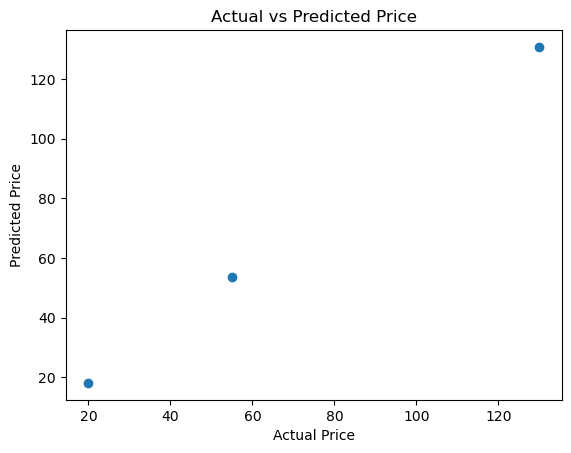


Conclusion:
Linear Regression model successfully predicts house prices.
Price increases with size, rooms, and better location.


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# Step 1: Create Dataset (No Kaggle error)
# -------------------------------

data = {
    "Rooms": [1,2,2,3,3,4,4,5,5,6,2,3,4,5,6],
    "Size": [500,700,800,1000,1200,1500,1600,1800,2000,2400,750,1100,1400,1900,2500],
    "Location": ["A","A","B","B","C","C","D","D","E","E","B","C","D","E","A"],
    "Price": [20,30,35,50,60,75,80,90,110,130,33,55,78,100,140]
}

df = pd.DataFrame(data)

# Save CSV (for submission proof)
df.to_csv("house_price_dataset.csv", index=False)

print("Dataset Created Successfully!\n")
print(df.head())

# -------------------------------
# Step 2: Preprocessing
# -------------------------------

# Convert categorical "Location" into numeric
le = LabelEncoder()
df["Location"] = le.fit_transform(df["Location"])

# Features & Target
X = df[["Rooms", "Size", "Location"]]
y = df["Price"]

# -------------------------------
# Step 3: Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 4: Model Training
# -------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Trained Successfully!")

# -------------------------------
# Step 5: Prediction
# -------------------------------

y_pred = model.predict(X_test)

# -------------------------------
# Step 6: Evaluation
# -------------------------------

print("\nModel Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -------------------------------
# Step 7: Predict New House
# -------------------------------

new_house = pd.DataFrame({
    "Rooms": [3],
    "Size": [1400],
    "Location": [le.transform(["C"])[0]]
})

predicted_price = model.predict(new_house)

print("\nNew House Prediction:")
print("Rooms: 3 | Size: 1400 | Location: C")
print("Predicted Price:", round(predicted_price[0],2), "Lakhs")

# -------------------------------
# Step 8: Visualization
# -------------------------------

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

# -------------------------------
# Conclusion (for report)
# -------------------------------

print("\nConclusion:")
print("Linear Regression model successfully predicts house prices.")
print("Price increases with size, rooms, and better location.")